### 중구 행사(축제)분석
* 산복하늘 빛의 거리(2021.11.22 ~ 2022.1.9)
* 부산크리스마스트리 문화축제(2021.12.4~2022.1.9)
* 분석대상기간 : 2021.10.4 ~ 2021.12.31

#### 분석환경 설정

In [17]:
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import pyplot, rcParams
import seaborn as sns

plt.rcParams['figure.figsize'] = (45,7)
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['font.size'] = 14
sns.set_palette('bright')

1. 요청기간(2021.11.22 ~ 2022.1.9)/증감비교기간(2021.10.4~2021.11.21) 내 성연령 유동인구 증감현황 : 12.31까지 적용
2. 요청기간(2021.11.22 ~ 2022.1.9)/증감비교기간(2021.10.4~2021.11.21) 내 시간대 유동인구 증감현황 : 12.31까지 적용

In [18]:
# 산복하늘 빛의 거리 성연령/시간대 현황
print("산복하늘 빛의 거리 내 성연령/시간대 유동인구 데이터 변환 시작")
pop11 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="성연령_유동인구_산복하늘빛의거리_1004-1231", encoding="utf-8")
pop12 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="시간대_유동인구_산복하늘빛의거리_1004-1231", encoding="utf-8")
print("산복하늘 빛의 거리 내 성연령/시간대 유동인구 데이터 변환 완료")
print("=" * 100)
# 산복하늘 빛의 거리 행사기간 내 소비매출 현황
print("산복하늘 빛의 거리 행사기간 내 소비매출 데이터 변환 시작")
card11 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="업종별_소비매출_산복하늘빛의거리_1004-1231", encoding="utf-8")
card11.rename(columns={'CARD_USE_AMOUNT':'이용금액', 'CARD_USE_CO':'이용건수'}, inplace=True)
print("산복하늘 빛의 거리 행사기간 내 소비매출 데이터 변환 완료")
print("=" * 100)
# 부산크리스마스트리 문화축제 성연령/시간대 현황
print("부산크리스마스트리 내 성연령/시간대 유동인구 데이터 변환 시작")
pop21 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="성연령_유동인구_부산크리스마스트리_1028-1231", encoding="utf-8")
pop22 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="시간대_유동인구_부산크리스마스트리_1028-1231", encoding="utf-8")
print("부산크리스마스트리 내 성연령/시간대 유동인구 데이터 변환 완료")
print("=" * 100)
# 부산크리스마스트리 행사기간 내 소비매출 현황
print("부산크리스마스트리 행사기간 내 소비매출 데이터 변환 시작")
card21 = gpd.read_file("./Gpkg/pop_card_data.gpkg", layer="업종별_소비매출_부산크리스마스트리_1028-1231", encoding="utf-8")
card21.rename(columns={'CARD_USE_AMOUNT':'이용금액', 'CARD_USE_CO':'이용건수'}, inplace=True)
print("부산크리스마스트리 행사기간 내 소비매출 데이터 변환 완료")
print("=" * 100)

산복하늘 빛의 거리 내 성연령/시간대 유동인구 데이터 변환 시작
산복하늘 빛의 거리 내 성연령/시간대 유동인구 데이터 변환 완료
산복하늘 빛의 거리 행사기간 내 소비매출 데이터 변환 시작
산복하늘 빛의 거리 행사기간 내 소비매출 데이터 변환 완료
부산크리스마스트리 내 성연령/시간대 유동인구 데이터 변환 시작
부산크리스마스트리 내 성연령/시간대 유동인구 데이터 변환 완료
부산크리스마스트리 행사기간 내 소비매출 데이터 변환 시작
부산크리스마스트리 행사기간 내 소비매출 데이터 변환 완료


3. 성연령별(10세 단위) 이동건수 집계

In [19]:
# 남자 10세 단위 집계
print("남자 10세 단위 집계 시작")
def man_10age_agg(df):
    df['M_1019'] = df['H_M_1014'] + df['H_M_1519'] + df['W_M_1014'] + df['W_M_1519'] + df['V_M_1014'] + df['V_M_1519']
    df['M_2029'] = df['H_M_2024'] + df['H_M_2529'] + df['W_M_2024'] + df['W_M_2529'] + df['V_M_2024'] + df['V_M_2529']
    df['M_3039'] = df['H_M_3034'] + df['H_M_3539'] + df['W_M_3034'] + df['W_M_3539'] + df['V_M_3034'] + df['V_M_3539']
    df['M_4049'] = df['H_M_4044'] + df['H_M_4549'] + df['W_M_4044'] + df['W_M_4549'] + df['V_M_4044'] + df['V_M_4549']
    df['M_5059'] = df['H_M_5054'] + df['H_M_5559'] + df['W_M_5054'] + df['W_M_5559'] + df['V_M_5054'] + df['V_M_5559']
    df['M_6069'] = df['H_M_6064'] + df['H_M_6569'] + df['W_M_6064'] + df['W_M_6569'] + df['V_M_6064'] + df['V_M_6569']
    df['M_7000'] = df['H_M_7000'] + df['H_M_7000'] + df['W_M_7000'] + df['W_M_7000'] + df['V_M_7000'] + df['V_M_7000']
man_10age_agg(pop11)
man_10age_agg(pop21)
print("남자 10세 단위 집계 완료")
print("=" * 100)

# 여자 10세 단위 집계
print("여자 10세 단위 집계 시작")
def wmn_10age_agg(df):
    df['W_1019'] = df['H_W_1014'] + df['H_W_1519'] + df['W_W_1014'] + df['W_W_1519'] + df['V_W_1014'] + df['V_W_1519']
    df['W_2029'] = df['H_W_2024'] + df['H_W_2529'] + df['W_W_2024'] + df['W_W_2529'] + df['V_W_2024'] + df['V_W_2529']
    df['W_3039'] = df['H_W_3034'] + df['H_W_3539'] + df['W_W_3034'] + df['W_W_3539'] + df['V_W_3034'] + df['V_W_3539']
    df['W_4049'] = df['H_W_4044'] + df['H_W_4549'] + df['W_W_4044'] + df['W_W_4549'] + df['V_W_4044'] + df['V_W_4549']
    df['W_5059'] = df['H_W_5054'] + df['H_W_5559'] + df['W_W_5054'] + df['W_W_5559'] + df['V_W_5054'] + df['V_W_5559']
    df['W_6069'] = df['H_W_6064'] + df['H_W_6569'] + df['W_W_6064'] + df['W_W_6569'] + df['V_W_6064'] + df['V_W_6569']
    df['W_7000'] = df['H_W_7000'] + df['H_W_7000'] + df['W_W_7000'] + df['W_W_7000'] + df['V_W_7000'] + df['V_W_7000']
wmn_10age_agg(pop11)
wmn_10age_agg(pop21)
print("여자 10세 단위 집계 완료")
print("=" * 100)

# 시간대별 집계
print("시간대별 유동인구 집계 시작")
def time_agg(df):
    df['SUM_18'] = df['H_T_18'] + df['W_T_18'] + df['V_T_18']
    df['SUM_19'] = df['H_T_19'] + df['W_T_19'] + df['V_T_19']
    df['SUM_20'] = df['H_T_20'] + df['W_T_20'] + df['V_T_20']
    df['SUM_21'] = df['H_T_21'] + df['W_T_21'] + df['V_T_21']
time_agg(pop12)
time_agg(pop22)
print("시간대별 유동인구 집계 완료")
print("=" * 100)

# 데이터타입 변환
print("데이터타입 변환 시작")
def convert_type(df):
    df['STD_YMD'] = df['STD_YMD'].astype(str)
convert_type(pop11)
convert_type(pop12)
convert_type(pop21)
convert_type(pop22)
print("데이터타입 변환 완료")
print("=" * 100)

# 기준연월일 기준으로 주 단위 표시
print("행사(축제)대상기간을 주 단위로 표시 시작")
def collect_week(df):
    df.loc[df['STD_YMD'].str.contains('20211004|20211005|20211006|20211007|20211008|20211009|20211010'), '대상기간(주)'] = '10월1주'
    df.loc[df['STD_YMD'].str.contains('20211011|20211012|20211013|20211014|20211015|20211016|20211017'), '대상기간(주)'] = '10월2주'
    df.loc[df['STD_YMD'].str.contains('20211018|20211019|20211020|20211021|20211022|20211023|20211024'), '대상기간(주)'] = '10월3주'
    df.loc[df['STD_YMD'].str.contains('20211025|20211026|20211027|20211028|20211029|20211030|20211031'), '대상기간(주)'] = '10월4주'
    df.loc[df['STD_YMD'].str.contains('20211101|20211102|20211103|20211104|20211105|20211106|20211107'), '대상기간(주)'] = '11월1주'
    df.loc[df['STD_YMD'].str.contains('20211108|20211109|20211110|20211111|20211112|20211113|20211114'), '대상기간(주)'] = '11월2주'
    df.loc[df['STD_YMD'].str.contains('20211115|20211116|20211117|20211118|20211119|20211120|20211121'), '대상기간(주)'] = '11월3주'
    df.loc[df['STD_YMD'].str.contains('20211122|20211123|20211124|20211125|20211126|20211127|20211128'), '대상기간(주)'] = '11월4주'
    df.loc[df['STD_YMD'].str.contains('20211129|20211130|20211201|20211202|20211203|20211204|20211205'), '대상기간(주)'] = '11월5주'
    df.loc[df['STD_YMD'].str.contains('20211206|20211207|20211208|20211209|20211210|20211211|20211212'), '대상기간(주)'] = '12월1주'
    df.loc[df['STD_YMD'].str.contains('20211213|20211214|20211215|20211216|20211217|20211218|20211219'), '대상기간(주)'] = '12월2주'
    df.loc[df['STD_YMD'].str.contains('20211220|20211221|20211222|20211223|20211224|20211225|20211226'), '대상기간(주)'] = '12월3주'
    df.loc[df['STD_YMD'].str.contains('20211227|20211228|20211229|20211230|20211231'), '대상기간(주)'] = '12월4주'
collect_week(pop11)
collect_week(pop12)
collect_week(card11)
collect_week(pop21)
collect_week(pop22)
collect_week(card21)
print("행사(축제)대상기간을 주 단위로 표시 완료")
print(pop11.head())
print(pop12.head())
print(card11.head())
print(pop21.head())
print(pop22.head())
print(card21.head())
print("=" * 100)

# 소비매출 데이터 정제
# 업종별 코드값 추가
print("업종별 소비매출 데이터 정제 시작")
def code_values(df):
    df.loc[df['INDUTY_SE_MLSFC'].str.contains('M001'), '업종중분류'] = '한식'
    df.loc[df['INDUTY_SE_MLSFC'].str.contains('M002'), '업종중분류'] = '일식/중식/양식'
    df.loc[df['INDUTY_SE_MLSFC'].str.contains('M003'), '업종중분류'] = '제과/커피/패스트푸드'
    df.loc[df['INDUTY_SE_MLSFC'].str.contains('M004'), '업종중분류'] = '기타요식'
    df.loc[df['SEXDSTN_CODE'].str.contains('M'), '남여별'] = '남'
    df.loc[df['SEXDSTN_CODE'].str.contains('F'), '남여별'] = '여'
    df.loc[df['AGRDE_CODE'].str.contains('1'), '연령별'] = '20대미만'
    df.loc[df['AGRDE_CODE'].str.contains('2'), '연령별'] = '20대'
    df.loc[df['AGRDE_CODE'].str.contains('3'), '연령별'] = '30대'
    df.loc[df['AGRDE_CODE'].str.contains('4'), '연령별'] = '40대'
    df.loc[df['AGRDE_CODE'].str.contains('5'), '연령별'] = '50대'
    df.loc[df['AGRDE_CODE'].str.contains('6'), '연령별'] = '60대'
    df.loc[df['AGRDE_CODE'].str.contains('7'), '연령별'] = '70대초과'
    df.loc[df['TMZON_CODE'].str.contains('18'), '시간대'] = '18시'
    df.loc[df['TMZON_CODE'].str.contains('19'), '시간대'] = '19시'
    df.loc[df['TMZON_CODE'].str.contains('20'), '시간대'] = '20시'
    df.loc[df['TMZON_CODE'].str.contains('21'), '시간대'] = '21시'
code_values(card11)
code_values(card21)
print("업종별 소비매출 데이터 정제 완료")
print(card11.head())
print(card21.head())
print("=" * 100)

# 성별, 연령별, 전체 집계
# 성별 집계 추가
print("행사(축제)별 행사기간 내 성별 집계 시작")
def gender_sum(df):
    df['SUM_M'] = df['M_1019'] + df['M_2029'] + df['M_3039'] + df['M_4049'] + df['M_5059'] + df['M_6069'] + df['M_7000']
    df['SUM_W'] = df['W_1019'] + df['W_2029'] + df['W_3039'] + df['W_4049'] + df['W_5059'] + df['W_6069'] + df['W_7000']
gender_sum(pop11)
gender_sum(pop21)
print("행사(축제)별 행사기간 내 성별 집계 완료")
print(pop11.head())
print(pop21.head())
print("=" * 100)

# 연령별 집계
print("행사(축제)별 행사기간 내 연령별 집계 시작")
def age_sum(df):
    df['SUM_1019'] = df['M_1019'] + df['W_1019']
    df['SUM_2029'] = df['M_2029'] + df['W_2029']
    df['SUM_3039'] = df['M_3039'] + df['W_3039']
    df['SUM_4049'] = df['M_4049'] + df['W_4049']
    df['SUM_5059'] = df['M_5059'] + df['W_5059']
    df['SUM_6069'] = df['M_6069'] + df['W_6069']
    df['SUM_7000'] = df['M_7000'] + df['W_7000']
age_sum(pop11)
age_sum(pop21)
print("행사(축제)별 행사기간 내 연령별 집계 완료")
print(pop11.head())
print(pop21.head())
print("=" * 100)

# 전체 집계
print("행사(축제)별 행사기간 내 전체 유동인구 집계 시작")
def all_sum(df):
    df['SUM_ALL'] = df['SUM_M'] + df['SUM_W']
all_sum(pop11)
all_sum(pop21)
print("행사(축제)별 행사기간 내 전체 유동인구 집계 완료")
print(pop11.head())
print(pop21.head())


남자 10세 단위 집계 시작
남자 10세 단위 집계 완료
여자 10세 단위 집계 시작
여자 10세 단위 집계 완료
시간대별 유동인구 집계 시작
시간대별 유동인구 집계 완료
데이터타입 변환 시작
데이터타입 변환 완료
행사(축제)대상기간을 주 단위로 표시 시작
행사(축제)대상기간을 주 단위로 표시 완료
    STD_YMD         HCODE       X_COORD       Y_COORD      BLOCK_CD  H_M_0009  \
0  20211001  2.611053e+09  1.139434e+06  1.680129e+06  2.101053e+19      0.22   
1  20211002  2.611053e+09  1.139434e+06  1.680129e+06  2.101053e+19      0.21   
2  20211003  2.611053e+09  1.139434e+06  1.680129e+06  2.101053e+19      0.21   
3  20211004  2.611053e+09  1.139434e+06  1.680129e+06  2.101053e+19      0.25   
4  20211005  2.611053e+09  1.139434e+06  1.680129e+06  2.101053e+19      0.21   

   H_M_1014  H_M_1519  H_M_2024  H_M_2529  ...  M_6069  M_7000  W_1019  \
0      0.12      0.14      0.19      0.18  ...    0.61    0.96    0.37   
1      0.11      0.16      0.19      0.19  ...    0.57    0.86    0.39   
2      0.10      0.18      0.21      0.20  ...    0.55    0.86    0.40   
3      0.12      0.18      0.21      0.20  ...   

4. 분석용 컬럼 정제

In [20]:
# 성연령별 집계를 위한 컬럼 정제
print("성연령별 유동인구 컬럼 정제 시작")
pop11_all1 = pop11[['대상기간(주)','SUM_ALL']]
pop11_gen1 = pop11[['대상기간(주)','SUM_M','SUM_W']]
pop11_age1 = pop11[['대상기간(주)','SUM_1019','SUM_2029','SUM_3039','SUM_4049','SUM_5059','SUM_6069','SUM_7000']]
pop21_all1 = pop21[['대상기간(주)','SUM_ALL']]
pop21_gen1 = pop21[['대상기간(주)','SUM_M','SUM_W','SUM_ALL']]
pop21_age1 = pop21[['대상기간(주)','SUM_1019','SUM_2029','SUM_3039','SUM_4049','SUM_5059','SUM_6069','SUM_7000']]
print(pop11_all1.head())
print(pop11_gen1.head())
print(pop11_age1.head())
print(pop21_all1.head())
print(pop21_gen1.head())
print(pop21_age1.head())
print("=" * 100)

# 시간대별 집계를 위한 컬럼 정제
print("시간대별 유동인구 컬럼 정제 시작")
pop12_tm1 = pop12[['대상기간(주)','SUM_18','SUM_19','SUM_20','SUM_21']]
pop22_tm1 = pop22[['대상기간(주)','SUM_18','SUM_19','SUM_20','SUM_21']]
print("시간대별 유동인구 컬럼 정제 완료")
print(pop12_tm1.head())
print(pop22_tm1.head())
print("=" * 100)

# 카드사용내역 집계를 위한 컬럼 정제
card11_cls = card11[['대상기간(주)','업종중분류','남여별','연령별','시간대','이용금액','이용건수']]
card21_cls = card21[['대상기간(주)','업종중분류','남여별','연령별','시간대','이용금액','이용건수']]

성연령별 유동인구 컬럼 정제 시작
  대상기간(주)  SUM_ALL
0     NaN    10.42
1     NaN     9.85
2     NaN     9.60
3   10월1주     9.98
4   10월1주    10.21
  대상기간(주)  SUM_M  SUM_W
0     NaN   4.65   5.77
1     NaN   4.46   5.39
2     NaN   4.35   5.25
3   10월1주   4.47   5.51
4   10월1주   4.54   5.67
  대상기간(주)  SUM_1019  SUM_2029  SUM_3039  SUM_4049  SUM_5059  SUM_6069  \
0     NaN      0.77      1.28      1.29      1.51      1.81      1.38   
1     NaN      0.75      1.28      1.17      1.43      1.71      1.29   
2     NaN      0.75      1.25      1.19      1.39      1.59      1.23   
3   10월1주      0.74      1.27      1.19      1.41      1.69      1.36   
4   10월1주      0.76      1.21      1.27      1.48      1.81      1.38   

   SUM_7000  
0      2.38  
1      2.22  
2      2.20  
3      2.32  
4      2.30  
  대상기간(주)  SUM_ALL
0   10월4주    36.51
1   10월4주    38.92
2   10월4주    35.86
3   10월4주    33.15
4   10월4주     2.23
  대상기간(주)  SUM_M  SUM_W  SUM_ALL
0   10월4주  18.33  18.18    36.51
1   10월4주  19.54  19

5. 데이터 재구조화

In [21]:
# 성연령별 집계 데이터 재구조화
print("유동인구 전체 및 성연령별 집계 데이터 재구조화 시작")
pop11_all2 = pd.melt(pop11_all1, id_vars='대상기간(주)', value_vars='SUM_ALL', var_name='유동인구전체', value_name='이동건수(집계)')
pop11_gen2 = pd.melt(pop11_gen1, id_vars='대상기간(주)', value_vars=['SUM_M','SUM_W'], var_name='남여별', value_name='이동건수(집계)')
pop11_age2 = pd.melt(pop11_age1, id_vars='대상기간(주)', value_vars=['SUM_1019','SUM_2029','SUM_3039','SUM_4049','SUM_5059','SUM_6069','SUM_7000'],
                     var_name='연령별', value_name='이동건수(집계)')
pop21_all2 = pd.melt(pop21_all1, id_vars='대상기간(주)', value_vars='SUM_ALL', var_name='유동인구전체', value_name='이동건수(집계)')
pop21_gen2 = pd.melt(pop21_gen1, id_vars='대상기간(주)', value_vars=['SUM_M','SUM_W'], var_name='남여별', value_name='이동건수(집계)')
pop21_age2 = pd.melt(pop21_age1, id_vars='대상기간(주)', value_vars=['SUM_1019','SUM_2029','SUM_3039','SUM_4049','SUM_5059','SUM_6069','SUM_7000'],
                     var_name='연령별', value_name='이동건수(집계)')
print("유동인구 전체 및 성연령별 집계 데이터 재구조화 완료")
print(pop11_all2)
print(pop11_gen2)
print(pop11_age2)
print(pop21_all2)
print(pop21_gen2)
print(pop21_age2)
print("=" * 100)

# 시간대 집계 데이터 재구조화
print("시간대별 집계 데이터 재구조화 시작")
pop12_tm2 = pd.melt(pop12_tm1, id_vars='대상기간(주)', value_vars=['SUM_18','SUM_19','SUM_20','SUM_21'], var_name='시간대', value_name='이동건수(집계)')
pop22_tm2 = pd.melt(pop22_tm1, id_vars='대상기간(주)', value_vars=['SUM_18','SUM_19','SUM_20','SUM_21'], var_name='시간대', value_name='이동건수(집계)')
print("시간대별 집계 데이터 재구조화 완료")
print(pop12_tm2)
print(pop22_tm2)
print("=" * 100)

유동인구 전체 및 성연령별 집계 데이터 재구조화 시작
유동인구 전체 및 성연령별 집계 데이터 재구조화 완료
     대상기간(주)   유동인구전체  이동건수(집계)
0        NaN  SUM_ALL     10.42
1        NaN  SUM_ALL      9.85
2        NaN  SUM_ALL      9.60
3      10월1주  SUM_ALL      9.98
4      10월1주  SUM_ALL     10.21
...      ...      ...       ...
5607   12월4주  SUM_ALL    355.29
5608   12월4주  SUM_ALL    350.57
5609   12월4주  SUM_ALL    352.68
5610   12월4주  SUM_ALL    355.35
5611   12월4주  SUM_ALL    362.63

[5612 rows x 3 columns]
      대상기간(주)    남여별  이동건수(집계)
0         NaN  SUM_M      4.65
1         NaN  SUM_M      4.46
2         NaN  SUM_M      4.35
3       10월1주  SUM_M      4.47
4       10월1주  SUM_M      4.54
...       ...    ...       ...
11219   12월4주  SUM_W    188.63
11220   12월4주  SUM_W    186.09
11221   12월4주  SUM_W    188.01
11222   12월4주  SUM_W    189.41
11223   12월4주  SUM_W    192.50

[11224 rows x 3 columns]
      대상기간(주)       연령별  이동건수(집계)
0         NaN  SUM_1019      0.77
1         NaN  SUM_1019      0.75
2         NaN  SUM_1019      0.

5. 시각화를 위한 집계데이터 구성

In [22]:
# 시각화를 위한 집계 : 유동인구
print("시각화용 집계데이터 생성 시작")
pop11_all3 = pop11_all2.groupby(['대상기간(주)','유동인구전체'])['이동건수(집계)'].sum().reset_index()
pop11_gen3 = pop11_gen2.groupby(['대상기간(주)','남여별'])['이동건수(집계)'].sum().reset_index()
pop11_age3 = pop11_age2.groupby(['대상기간(주)','연령별'])['이동건수(집계)'].sum().reset_index().sort_values(by='연령별')
pop12_tm3 = pop12_tm2.groupby(['대상기간(주)','시간대'])['이동건수(집계)'].sum().reset_index().sort_values(by='시간대')
pop21_all3 = pop21_all2.groupby(['대상기간(주)','유동인구전체'])['이동건수(집계)'].sum().reset_index()
pop21_gen3 = pop21_gen2.groupby(['대상기간(주)','남여별'])['이동건수(집계)'].sum().reset_index()
pop21_age3 = pop21_age2.groupby(['대상기간(주)','연령별'])['이동건수(집계)'].sum().reset_index().sort_values(by='연령별')
pop22_tm3 = pop22_tm2.groupby(['대상기간(주)','시간대'])['이동건수(집계)'].sum().reset_index().sort_values(by='시간대')
pop11_all3.to_csv("./Result/csv/산복하늘 빛의 거리_유동인구전체_집계.csv", encoding="cp949")
pop11_gen3.to_csv("./Result/csv/산복하늘 빛의 거리_남여별_집계.csv", encoding="cp949")
pop11_age3.to_csv("./Result/csv/산복하늘 빛의 거리_연령별_집계.csv", encoding="cp949")
pop12_tm3.to_csv("./Result/csv/산복하늘 빛의 거리_시간대_집계.csv", encoding="cp949")
pop21_all3.to_csv("./Result/csv/부산크리스마트트리_유동인구전체_집계.csv", encoding="cp949")
pop21_gen3.to_csv("./Result/csv/부산크리스마트트리_남여별_집계.csv", encoding="cp949")
pop21_age3.to_csv("./Result/csv/부산크리스마트트리_연령별_집계.csv", encoding="cp949")
pop22_tm3.to_csv("./Result/csv/부산크리스마트트리_시간대_집계.csv", encoding="cp949")
print("시각화용 집계데이터 생성 완료")
print("=" * 100)

# 시각화를 위한 집계 : 카드이용내역
print("업종중분류 성별 연령별 시간대 카드사용내역 집계 시작")
card11_kind = card11_cls.groupby(['대상기간(주)','업종중분류',])['이용건수','이용금액'].sum().reset_index().sort_values(by='업종중분류')
card11_gen = card11_cls.groupby(['대상기간(주)','남여별',])['이용건수','이용금액'].sum().reset_index()
card11_age = card11_cls.groupby(['대상기간(주)','연령별',])['이용건수','이용금액'].sum().reset_index().sort_values(by='연령별')
card11_tm = card11_cls.groupby(['대상기간(주)','시간대',])['이용건수','이용금액'].sum().reset_index().sort_values(by='시간대')
card21_kind = card21_cls.groupby(['대상기간(주)','업종중분류',])['이용건수','이용금액'].sum().reset_index().sort_values(by='업종중분류')
card21_gen = card21_cls.groupby(['대상기간(주)','남여별',])['이용건수','이용금액'].sum().reset_index()
card21_age = card21_cls.groupby(['대상기간(주)','연령별',])['이용건수','이용금액'].sum().reset_index().sort_values(by='연령별')
card21_tm = card21_cls.groupby(['대상기간(주)','시간대',])['이용건수','이용금액'].sum().reset_index().sort_values(by='시간대')
print("업종중분류 성별 연령별 시간대 카드사용내역 집계 완료")
print("=" * 100)

# 이용건수, 금액 단위조정(시인성 확보)
print("카드사용내역 집계단위 조정 시작")
def change_units(df):
    df['이용건수(백  건)'] = round(df['이용건수'] / 100)
    df['이용금액(백만원)'] = round(df['이용금액'] / 1000000)
change_units(card11_kind)
change_units(card11_gen)
change_units(card11_age)
change_units(card11_tm)
change_units(card21_kind)
change_units(card21_gen)
change_units(card21_age)
change_units(card21_tm)
print("카드사용내역 집계단위 조정 완료")
print("=" * 100)

print("집계데이터 생성 시작")
card11_kind.to_csv("./Result/csv/산복하늘 빛의 거리_업종별_이용현황_집계.csv", encoding="cp949")
card11_gen.to_csv("./Result/csv/산복하늘 빛의 거리_남여별_이용현황_집계.csv", encoding="cp949")
card11_age.to_csv("./Result/csv/산복하늘 빛의 거리_연령별_이용현황_집계.csv", encoding="cp949")
card11_tm.to_csv("./Result/csv/산복하늘 빛의 거리_시간대_이용현황_집계.csv", encoding="cp949")
card21_kind.to_csv("./Result/csv/부산크리스마스트리_업종별_이용현황_집계.csv", encoding="cp949")
card21_gen.to_csv("./Result/csv/부산크리스마스트리_남여별_이용현황_집계.csv", encoding="cp949")
card21_age.to_csv("./Result/csv/부산크리스마스트리_연령별_이용현황_집계.csv", encoding="cp949")
card21_tm.to_csv("./Result/csv/부산크리스마스트리_시간대_이용현황_집계.csv", encoding="cp949")
print("집계데이터 생성 완료")
print("=" * 100)

시각화용 집계데이터 생성 시작
시각화용 집계데이터 생성 완료
업종중분류 성별 연령별 시간대 카드사용내역 집계 시작
업종중분류 성별 연령별 시간대 카드사용내역 집계 완료
카드사용내역 집계단위 조정 시작
카드사용내역 집계단위 조정 완료
집계데이터 생성 시작
집계데이터 생성 완료


6. 시각화 구성(1)

산복하늘 빛의거리_유동인구전체-업종별 이용건수_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구전체-업종별이용건수_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구전체-업종별 이용금액 그래프 생성 시작
산복하늘 빛의거리_유동인구전체-업종별 이용금액 그래프 생성 완료
산복하늘 빛의거리_유동인구-남여별 이용건수_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구-남여별 이용건수_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-남여별 이용금액_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구-남여별 이용금액_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-연령별 이용건수_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구-연령별 이용건수_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-연령별 이용금액_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구-연령별 이용금액_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-시간대 이용건수_현황 그래프 생성 시작
산복하늘 빛의거리_유동인구-시간대 이용건수_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-시간대 이용금액_현황 그래프 생성 완료
산복하늘 빛의거리_유동인구-시간대 이용금액_현황 그래프 생성 완료


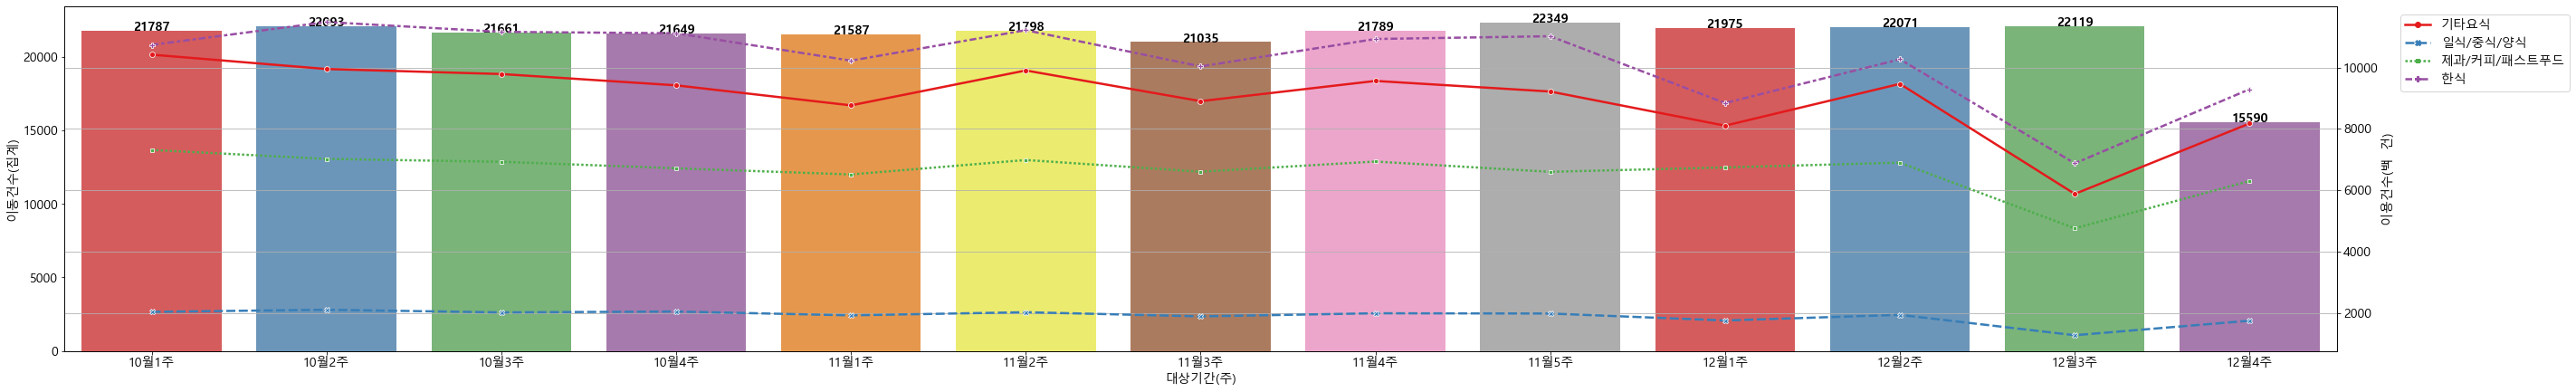

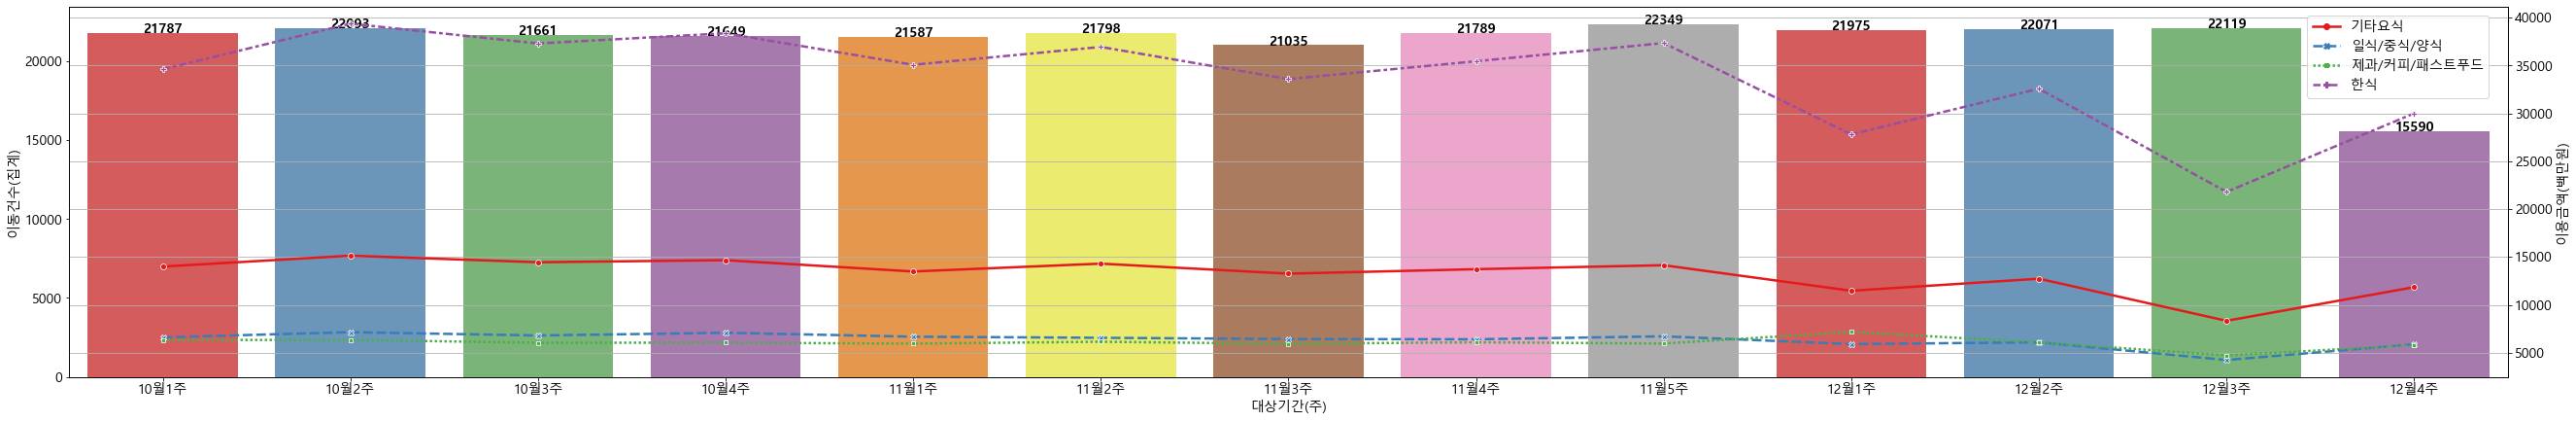

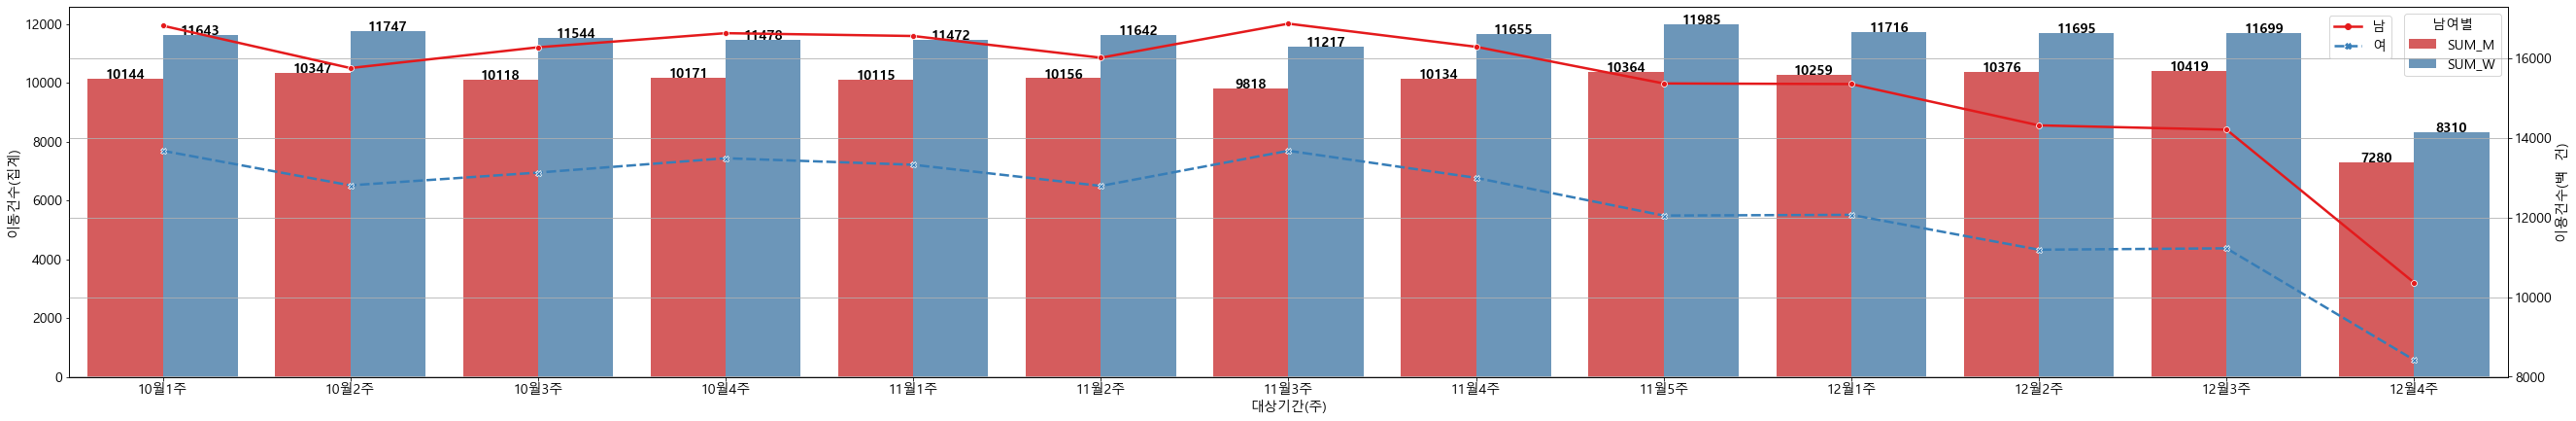

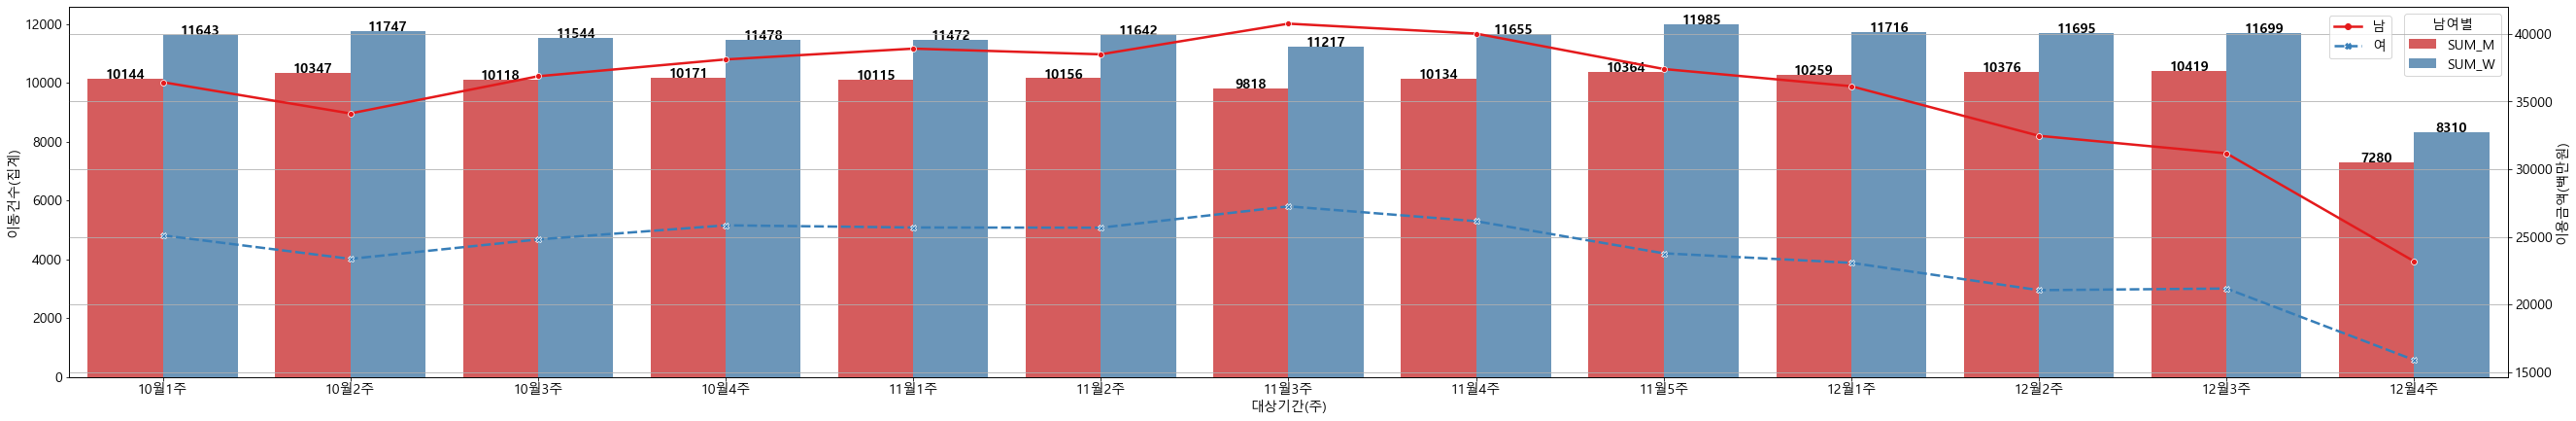

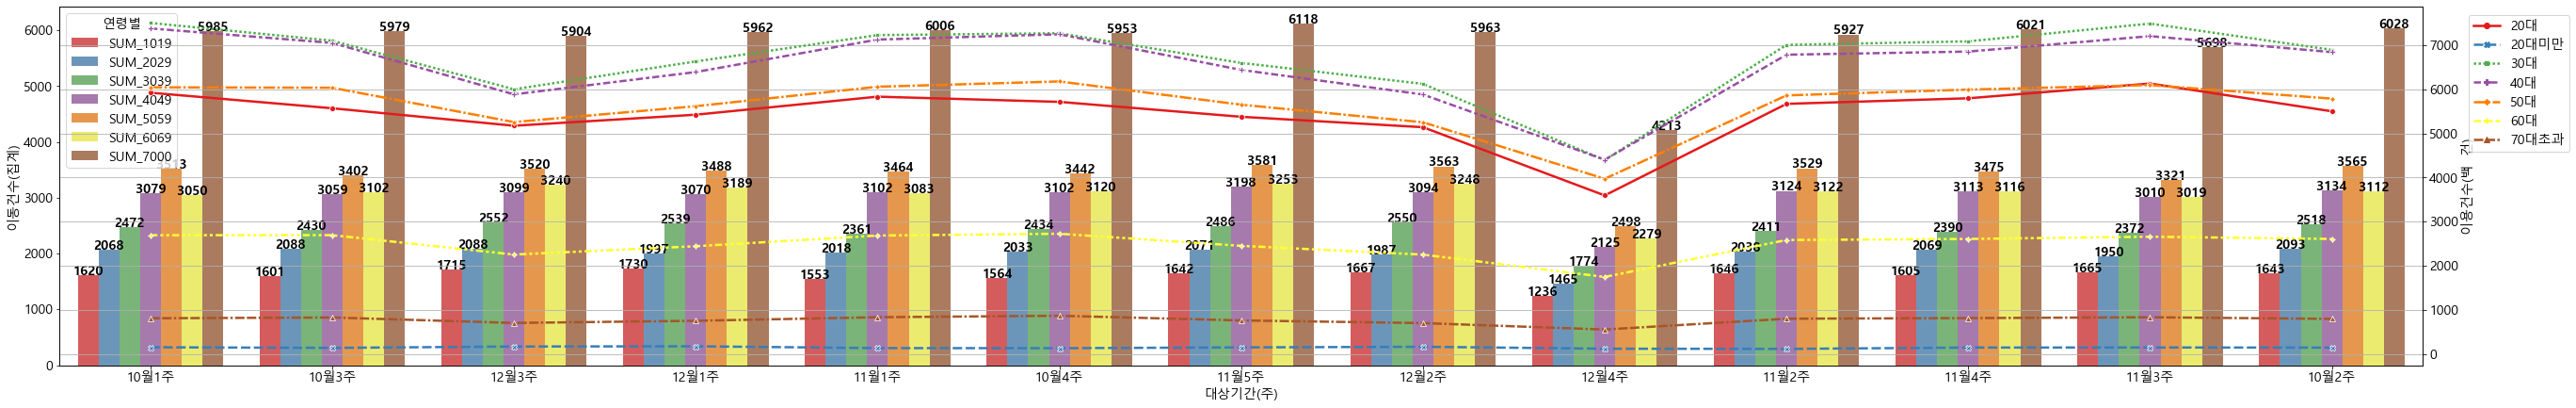

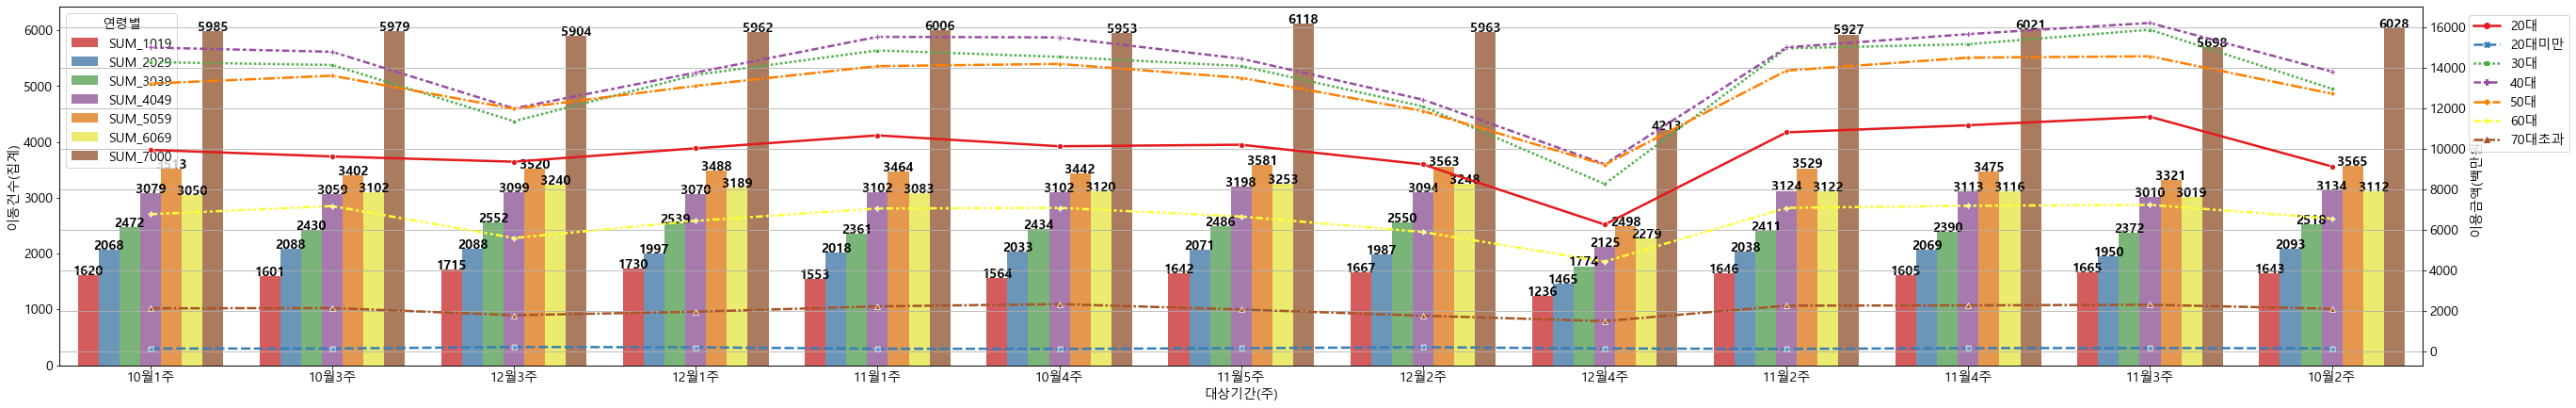

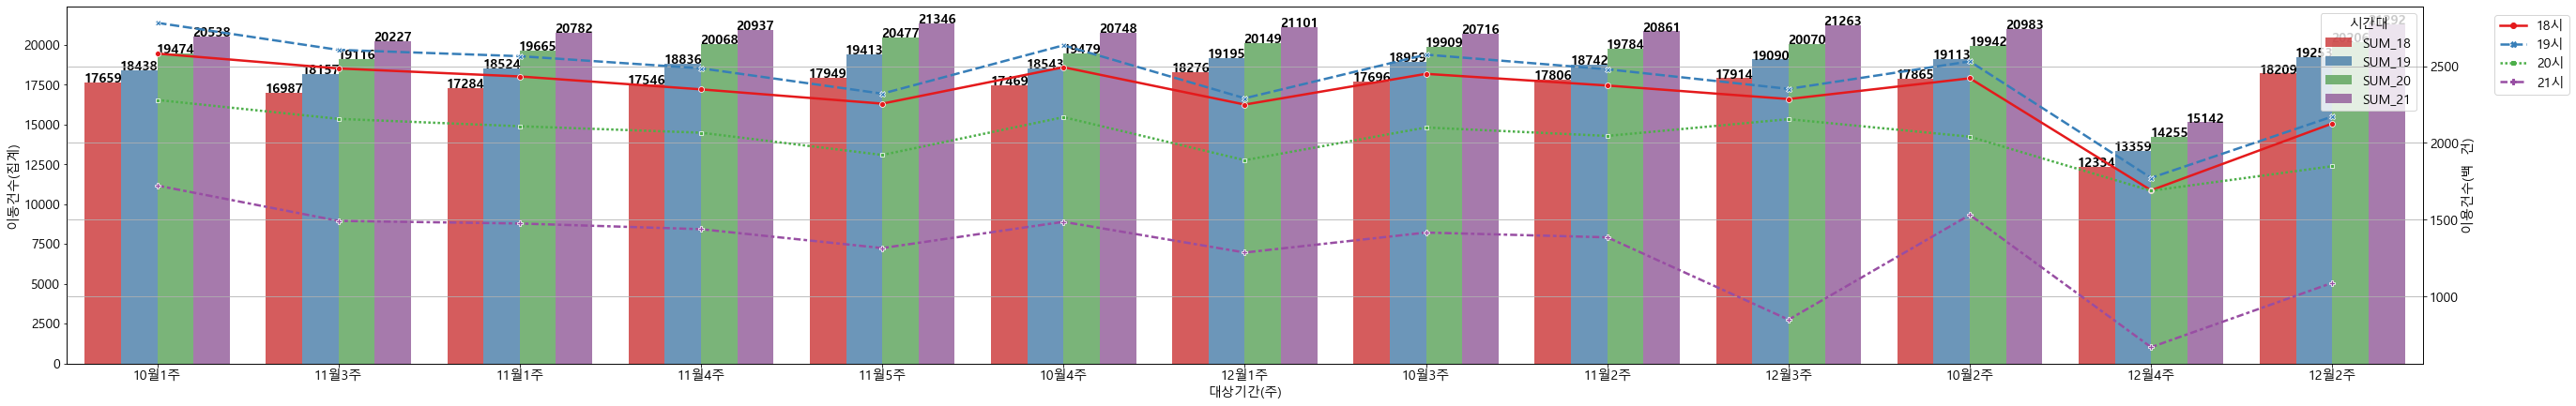

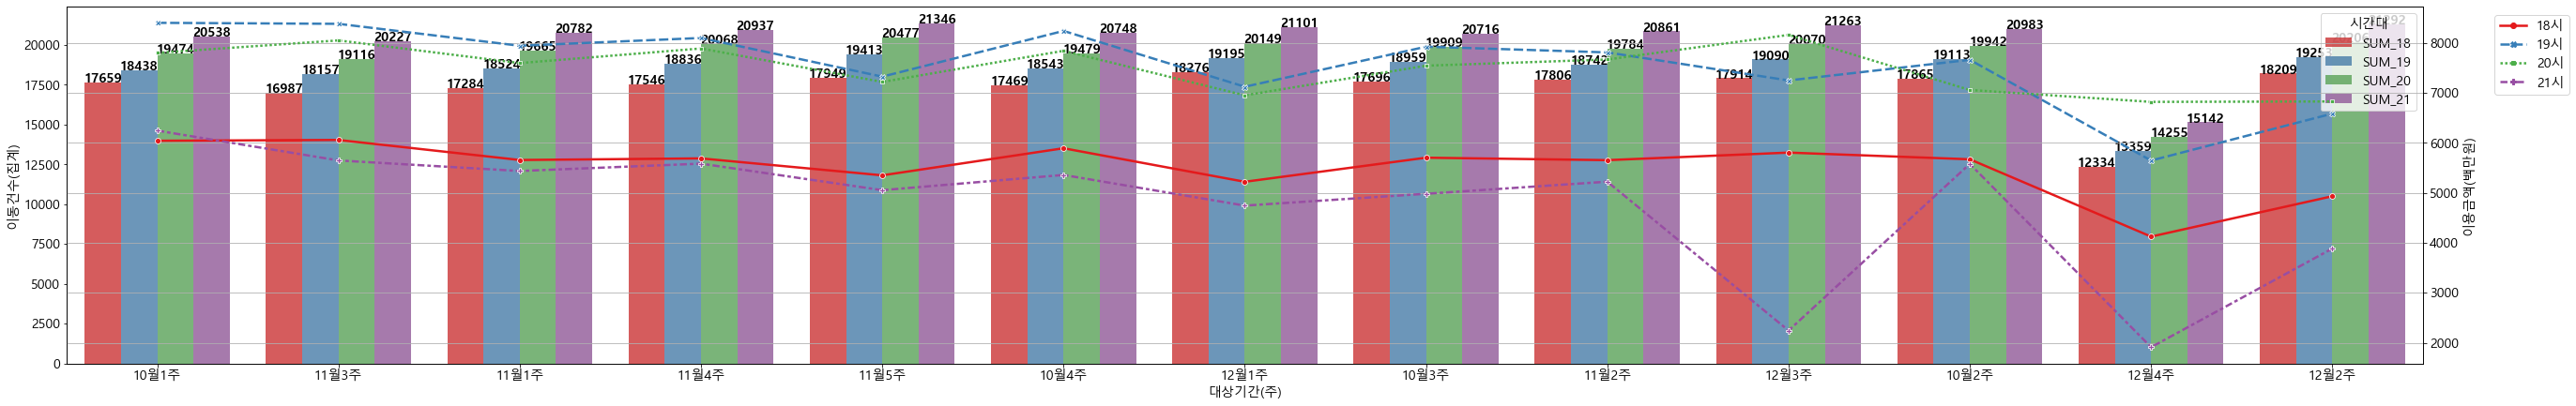

In [46]:
# 산복하늘 빛의 거리 행사기간 내 유동인구 전체와 업종별 카드이용건수 현황
print('산복하늘 빛의거리_유동인구전체-업종별 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card11_kind, hue='업종중분류', palette='Set1', ci=None, style='업종중분류', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_all3, palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x()+p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=15)
plt.legend(bbox_to_anchor=(1.025, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구전체-업종별 이용건수_현황.jpg")
print('산복하늘 빛의거리_유동인구전체-업종별이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 유동인구 전체와 업종별 카드이용금액 현황
print('산복하늘 빛의거리_유동인구전체-업종별 이용금액 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card11_kind, hue='업종중분류', palette='Set1', ci=None, style='업종중분류', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_all3, palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(0.995, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구전체-업종별 이용금액_현황.jpg")
print('산복하늘 빛의거리_유동인구전체-업종별 이용금액 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 남여별 유동인구현황과 카드이용건수 현황
print('산복하늘 빛의거리_유동인구-남여별 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card11_gen, hue='남여별', palette='Set1', ci=None, style='남여별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_gen3, hue='남여별', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(0.955, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-남여별 이용건수_현황.jpg")
print('산복하늘 빛의거리_유동인구-남여별 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 남여별 유동인구현황과 카드이용금액 현황
print('산복하늘 빛의거리_유동인구-남여별 이용금액_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card11_gen, hue='남여별', palette='Set1', ci=None, style='남여별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_gen3, hue='남여별', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(0.955, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-남여별 이용금액_현황.jpg")
print('산복하늘 빛의거리_유동인구-남여별 이용금액_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 연령별 유동인구현황과 카드이용건수 현황
print('산복하늘 빛의거리_유동인구-연령별 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card11_age, hue='연령별', palette='Set1', ci=None, style='연령별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_age3, hue='연령별', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-연령별 이용건수_현황.jpg")
print('산복하늘 빛의거리_유동인구-연령별 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 연령별 유동인구현황과 카드이용금액 현황
print('산복하늘 빛의거리_유동인구-연령별 이용금액_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card11_age, hue='연령별', palette='Set1', ci=None, style='연령별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop11_age3, hue='연령별', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-연령별 이용금액_현황.jpg")
print('산복하늘 빛의거리_유동인구-연령별 이용금액_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 시간대 유동인구현황과 카드이용건수 현황
print('산복하늘 빛의거리_유동인구-시간대 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card11_tm, hue='시간대', palette='Set1', ci=None, style='시간대', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop12_tm3, hue='시간대', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-시간대 이용건수_현황.jpg")
print('산복하늘 빛의거리_유동인구-시간대 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 연령별 유동인구현황과 카드이용금액 현황
print('산복하늘 빛의거리_유동인구-시간대 이용금액_현황 그래프 생성 완료')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card11_tm, hue='시간대', palette='Set1', ci=None, style='시간대', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop12_tm3, hue='시간대', palette='Set1', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-시간대 이용금액_현황.jpg")
print('산복하늘 빛의거리_유동인구-시간대 이용금액_현황 그래프 생성 완료')


6. 시각화 구성(2)

부산크리스마스트리 _유동인구전체-업종별이용건수_현황 그래프 생성 완료
부산크리스마스트리 _유동인구전체-업종별 이용금액_현황 그래프 생성 완료
부산크리스마스트리_유동인구-남여별 이용건수_현황 그래프 생성 시작
부산크리스마스트리_유동인구-남여별 이용건수_현황 그래프 생성 완료
부산크리스마스트리_유동인구-남여별 이용금액_현황 그래프 생성 시작
부산크리스마스트리_유동인구-남여별 이용금액_현황 그래프 생성 완료
부산크리스마스트리_유동인구-연령별 이용건수_현황 그래프 생성 시작
부산크리스마스트리_유동인구-연령별 이용건수_현황 그래프 생성 완료
부산크리스마스트리_유동인구-연령별 이용금액_현황 그래프 생성 시작
부산크리스마스트리_유동인구-연령별 이용금액_현황 그래프 생성 완료
부산크리스마스트리_유동인구-시간대 이용건수_현황 그래프 생성 시작
부산크리스마스트리_유동인구-시간대 이용건수_현황 그래프 생성 완료
부산크리스마스트리_유동인구-시간대 이용금액_현황 그래프 생성 완료
부산크리스마스트리_유동인구-시간대 이용금액_현황 그래프 생성 완료


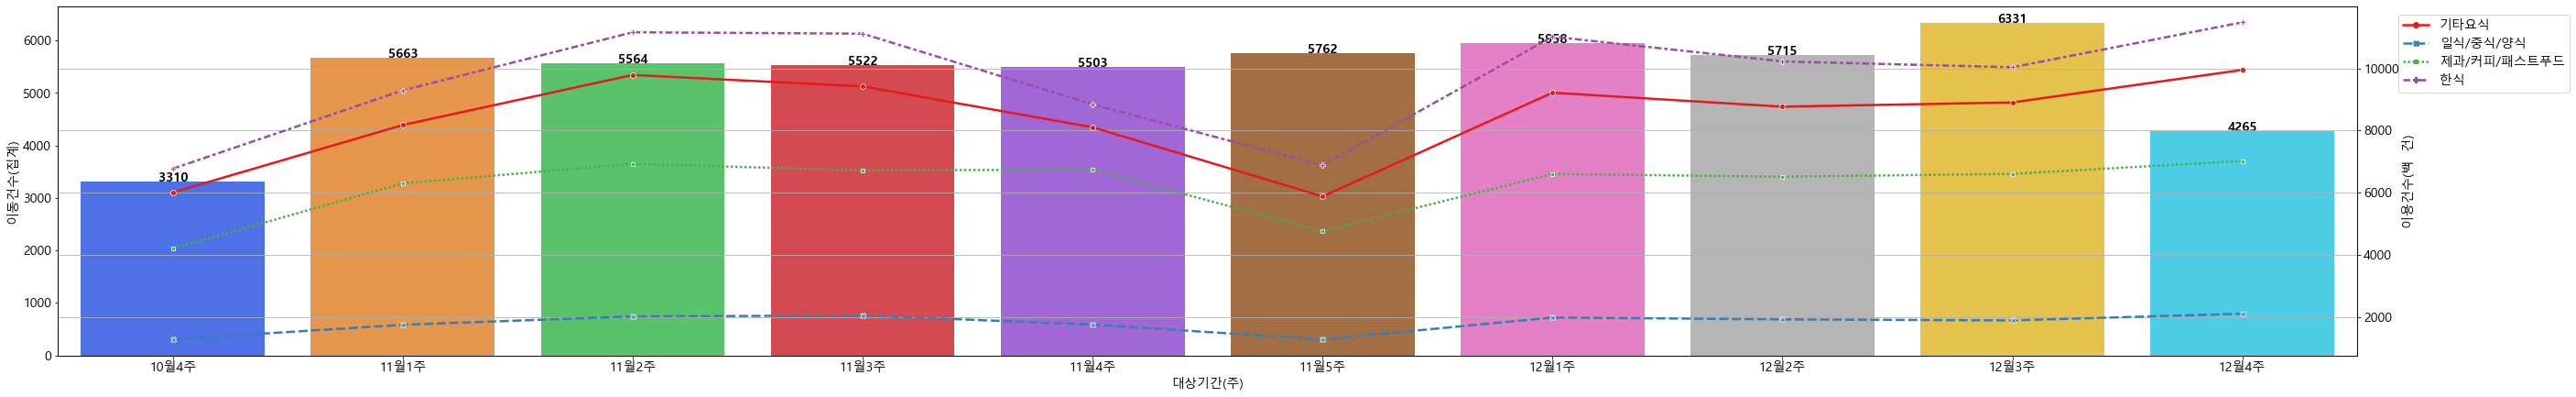

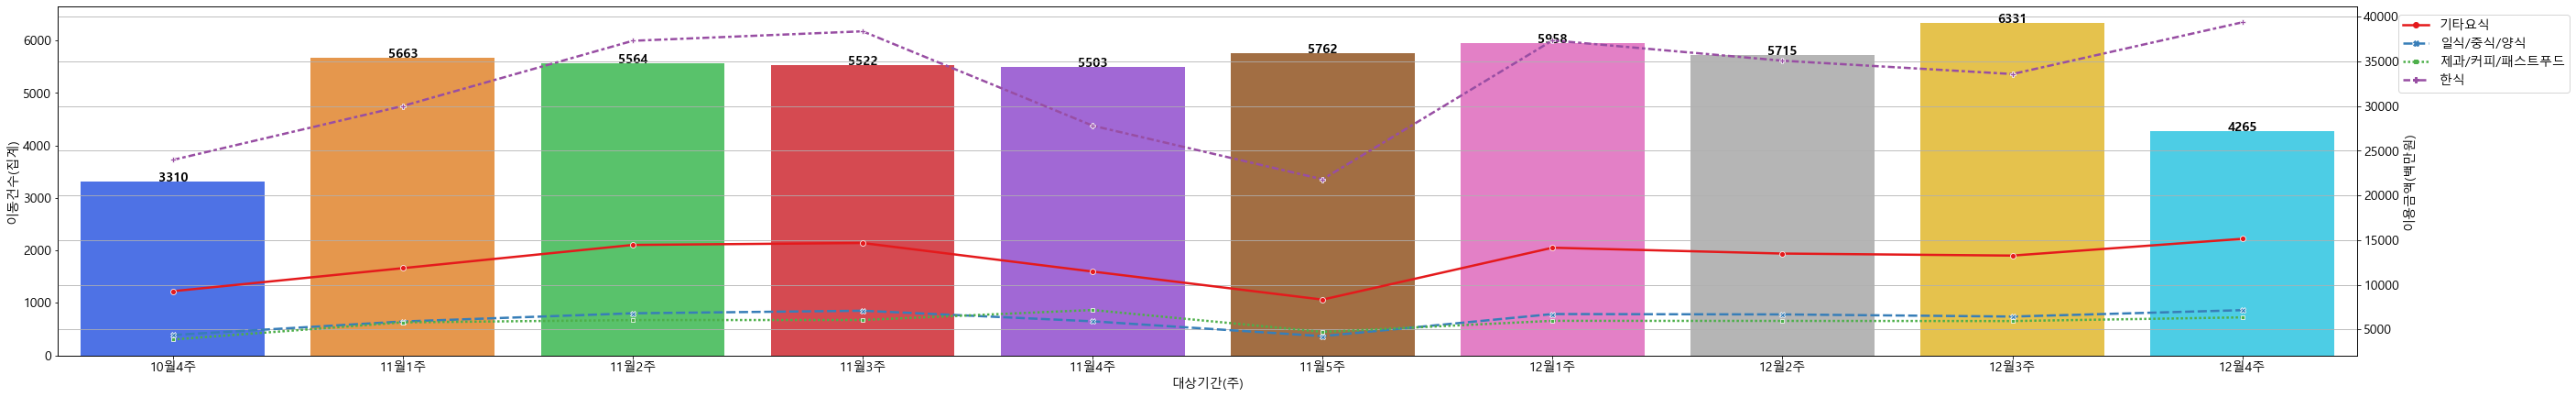

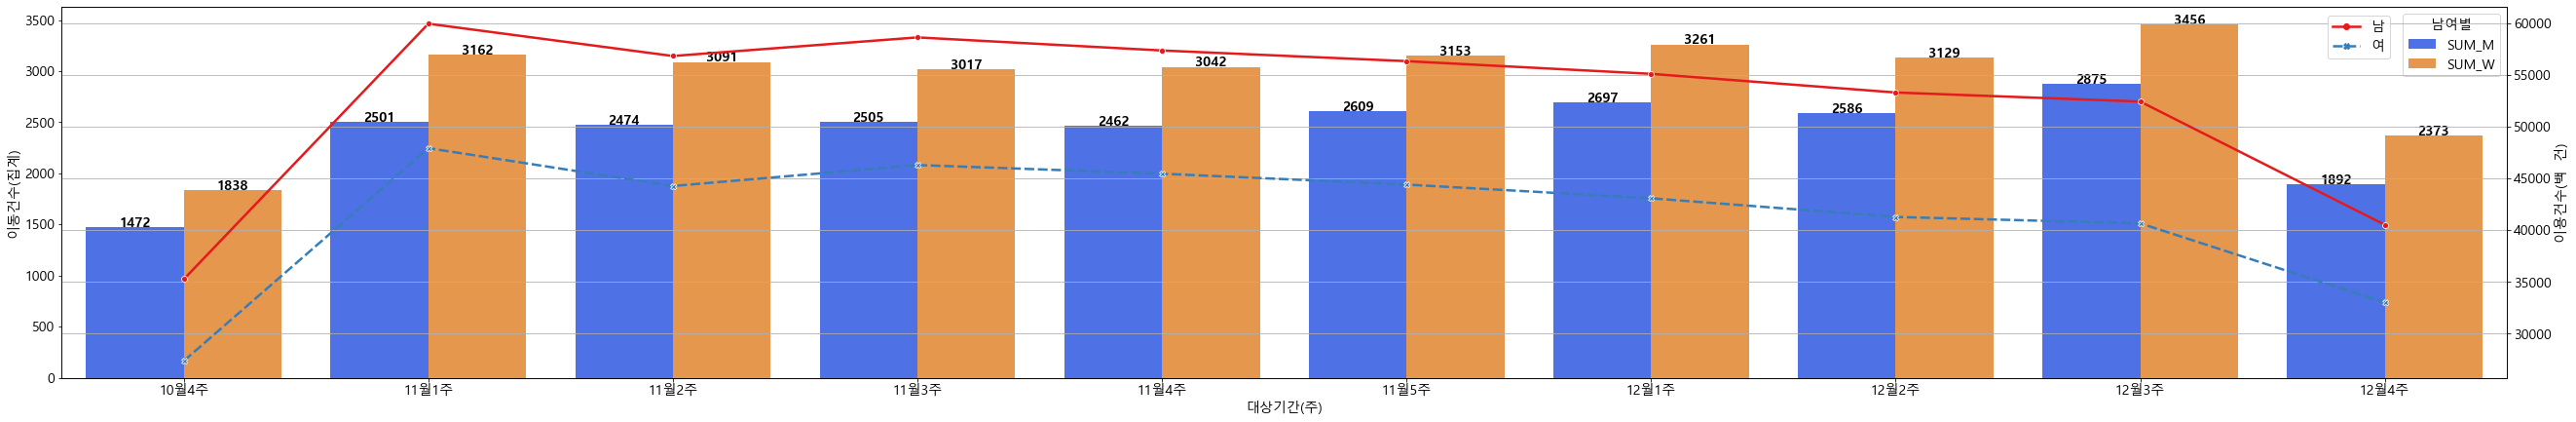

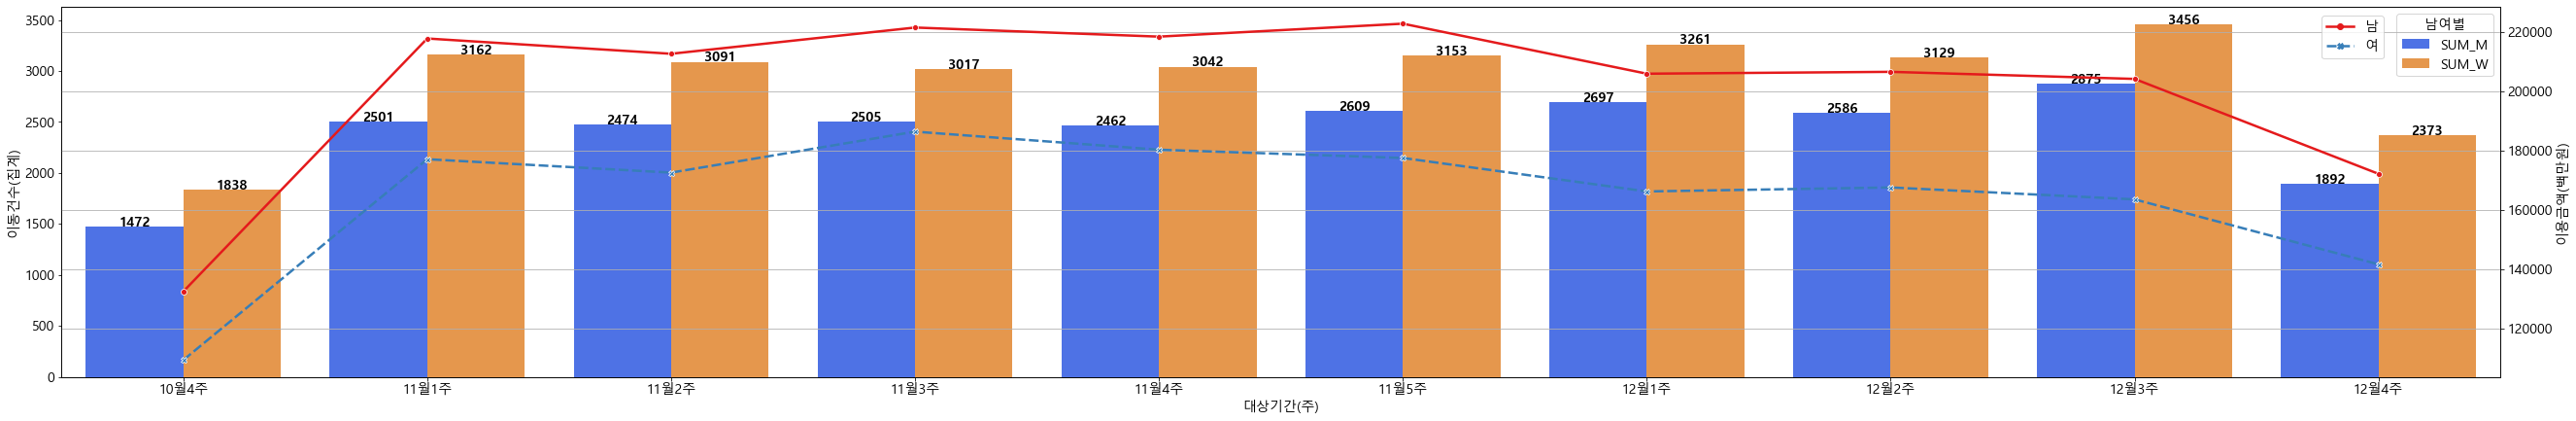

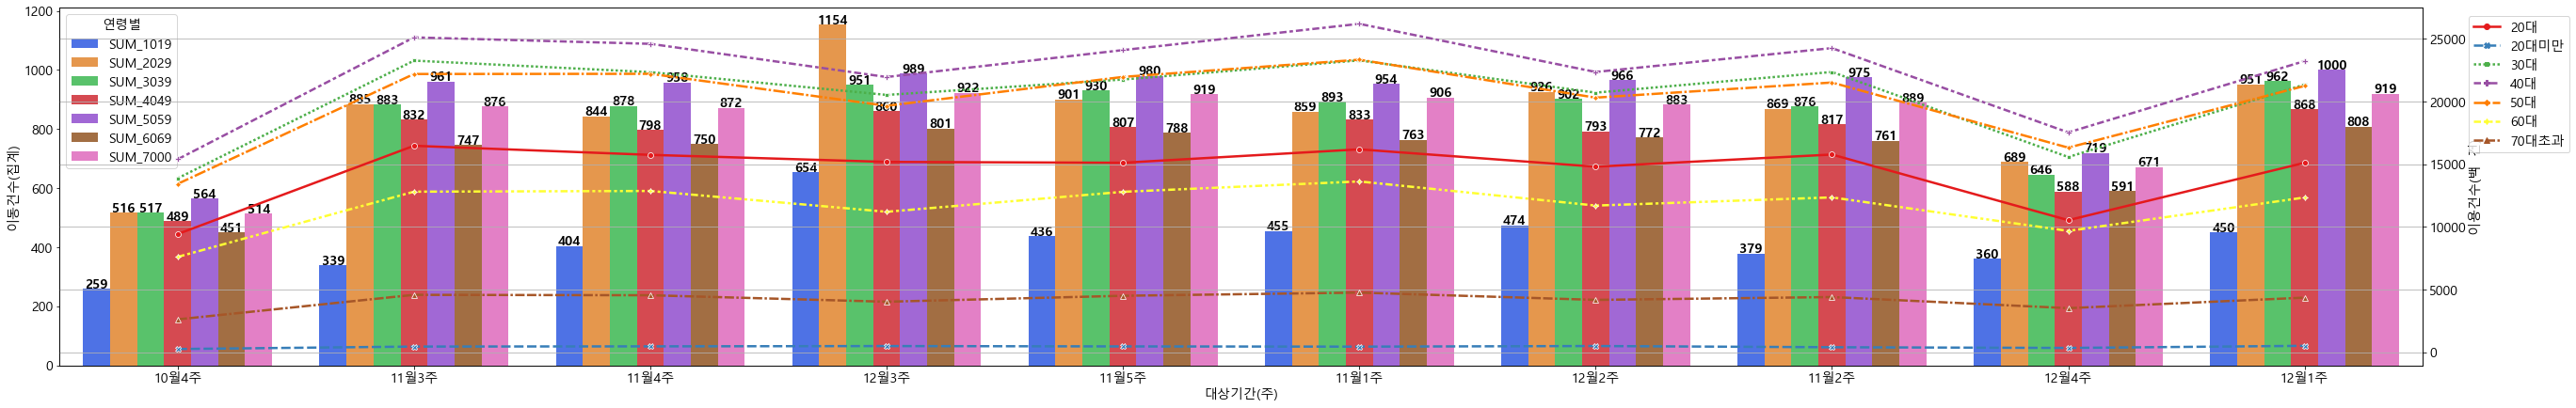

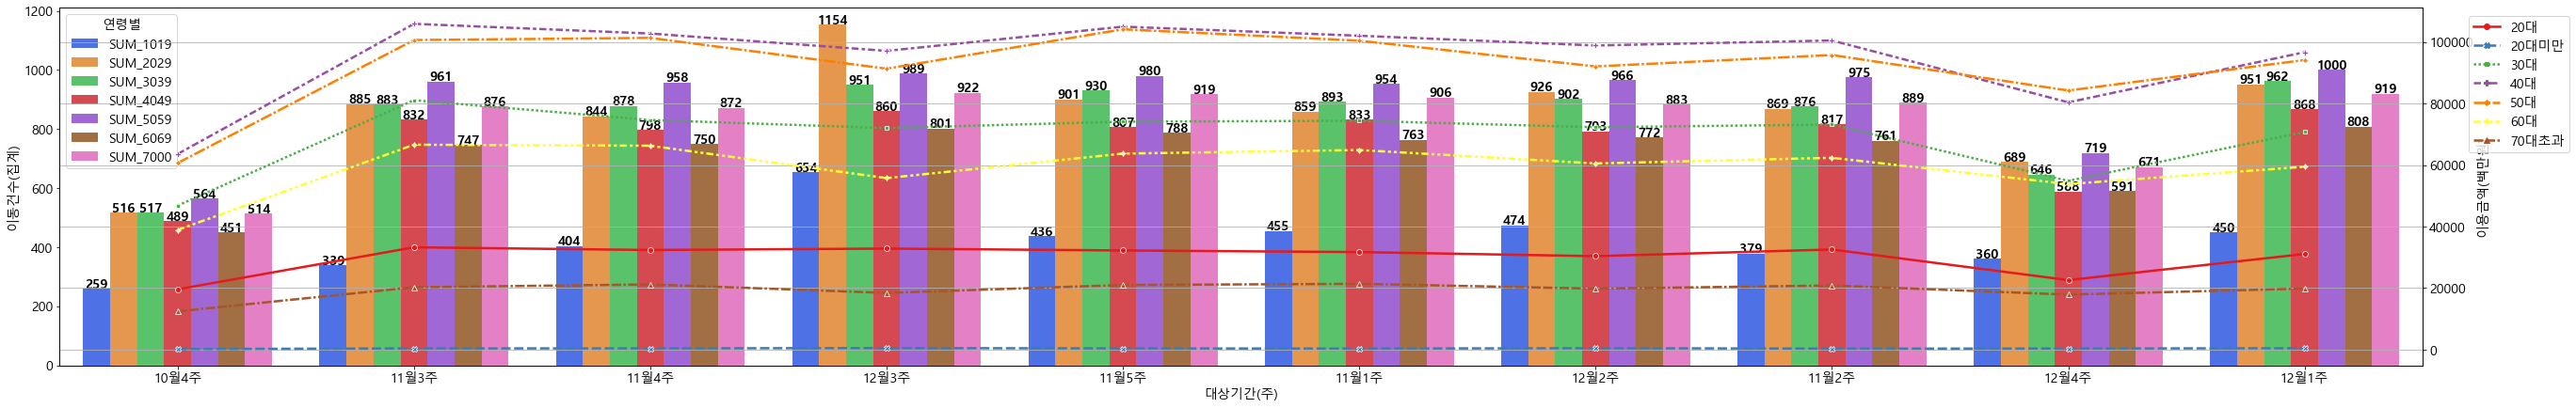

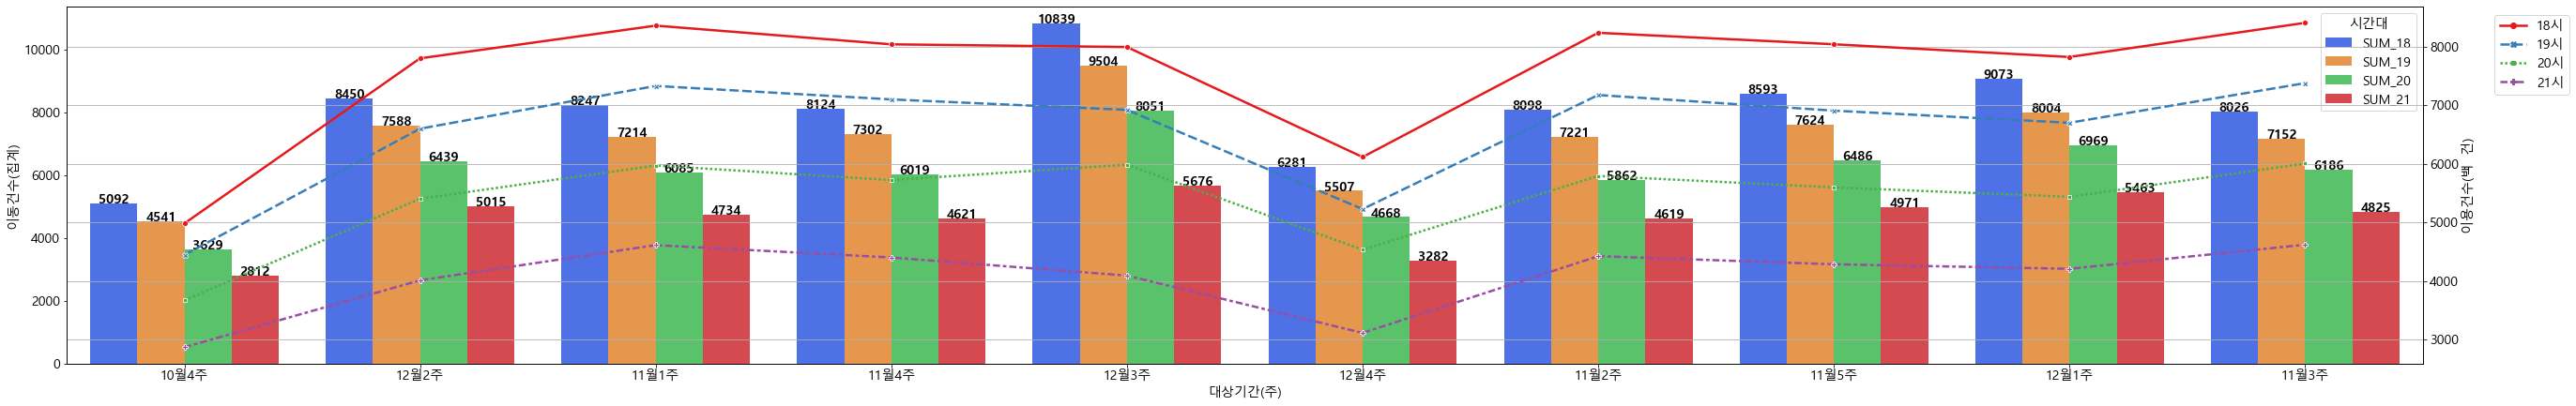

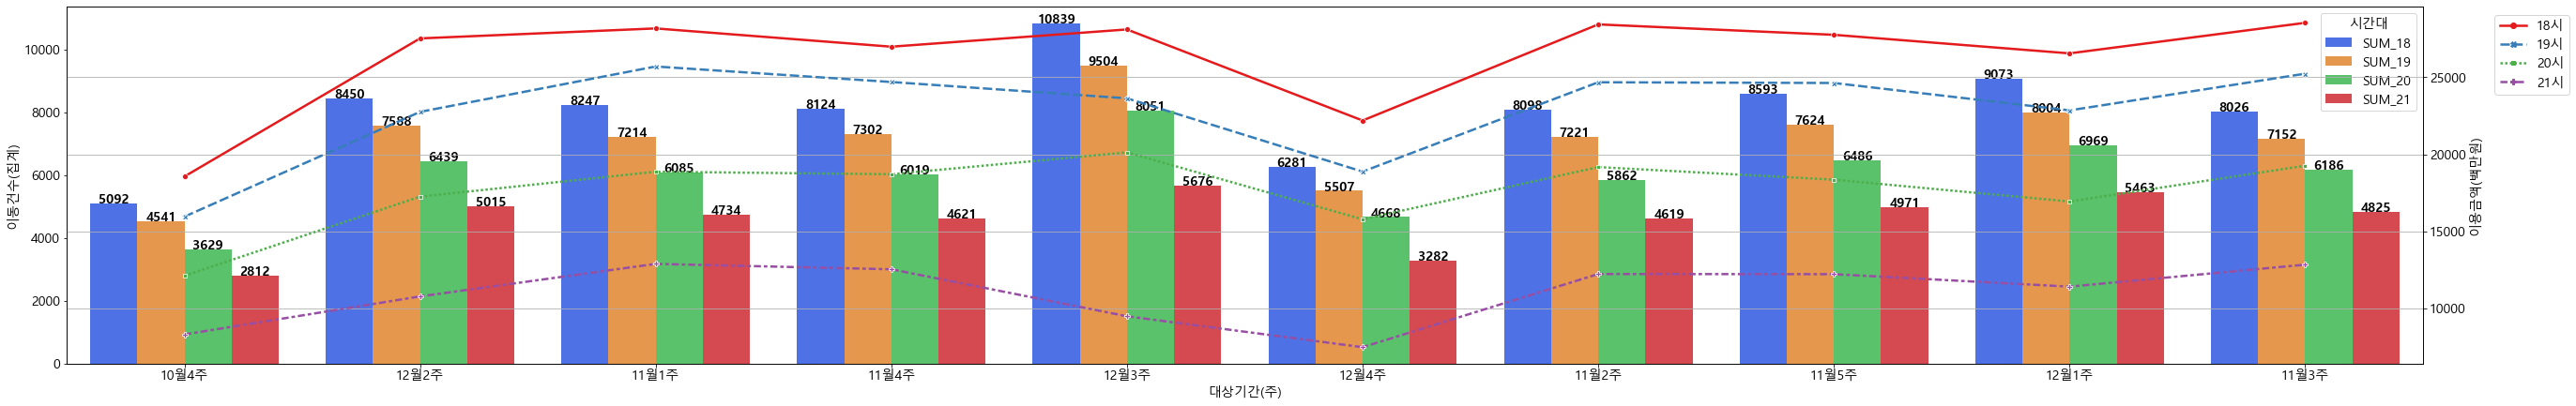

In [47]:
# 부산크리스마스트리 행사기간 내 유동인구 전체와 업종별 카드이용건수 현황
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card21_kind, hue='업종중분류', palette='Set1', ci=None, style='업종중분류', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_all3, ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x()+p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=15)
plt.legend(bbox_to_anchor=(1.015, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구전체-업종별이용건수_현황.jpg")
print('부산크리스마스트리 _유동인구전체-업종별이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 유동인구 전체와 업종별 카드이용금액 현황
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card21_kind, hue='업종중분류', palette='Set1', ci=None, style='업종중분류', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_all3, ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x()+p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=15)
plt.legend(bbox_to_anchor=(1.015, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구전체-업종별 이용금액_현황.jpg")
print('부산크리스마스트리 _유동인구전체-업종별 이용금액_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 남여별 유동인구현황과 카드이용건수 현황
print('부산크리스마스트리_유동인구-남여별 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card21_gen, hue='남여별', palette='Set1', ci=None, style='남여별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_gen3, hue='남여별', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(0.955, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-남여별 이용건수_현황.jpg")
print('부산크리스마스트리_유동인구-남여별 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 산복하늘 빛의 거리 행사기간 내 남여별 유동인구현황과 카드이용금액 현황
print('부산크리스마스트리_유동인구-남여별 이용금액_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card21_gen, hue='남여별', palette='Set1', ci=None, style='남여별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_gen3, hue='남여별', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(0.955, 0.995))
plt.grid(True)
plt.savefig("./Result/img/산복하늘 빛의거리_유동인구-남여별 이용금액_현황.jpg")
print('부산크리스마스트리_유동인구-남여별 이용금액_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 연령별 유동인구현황과 카드이용건수 현황
print('부산크리스마스트리_유동인구-연령별 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card21_age, hue='연령별', palette='Set1', ci=None, style='연령별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_age3, hue='연령별', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구-연령별 이용건수_현황.jpg")
print('부산크리스마스트리_유동인구-연령별 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 연령별 유동인구현황과 카드이용금액 현황
print('부산크리스마스트리_유동인구-연령별 이용금액_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card21_age, hue='연령별', palette='Set1', ci=None, style='연령별', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop21_age3, hue='연령별', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구-연령별 이용금액_현황.jpg")
print('부산크리스마스트리_유동인구-연령별 이용금액_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 시간대 유동인구현황과 카드이용건수 현황
print('부산크리스마스트리_유동인구-시간대 이용건수_현황 그래프 생성 시작')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용건수(백  건)', data=card21_tm, hue='시간대', palette='Set1', ci=None, style='시간대', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop22_tm3, hue='시간대', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구-시간대 이용건수_현황.jpg")
print('부산크리스마스트리_유동인구-시간대 이용건수_현황 그래프 생성 완료')
print("=" * 100)

# 부산크리스마스트리 행사기간 내 연령별 유동인구현황과 카드이용금액 현황
print('부산크리스마스트리_유동인구-시간대 이용금액_현황 그래프 생성 완료')
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
c1 = sns.lineplot(x='대상기간(주)', y='이용금액(백만원)', data=card21_tm, hue='시간대', palette='Set1', ci=None, style='시간대', markers=True, ax=ax2)
c2 = sns.barplot(x='대상기간(주)', y='이동건수(집계)', data=pop22_tm3, hue='시간대', ci=None, alpha=0.8, ax=ax1)
for p2 in c2.patches:
    height = p2.get_height()
    c2.text(p2.get_x() + p2.get_width()/2., height+3, round(height), ha='center', size=14, weight='bold')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation = 15)
plt.legend(bbox_to_anchor=(1.065, 0.995))
plt.grid(True)
plt.savefig("./Result/img/부산크리스마스트리_유동인구-시간대 이용금액_현황.jpg")
print('부산크리스마스트리_유동인구-시간대 이용금액_현황 그래프 생성 완료')
